In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [11]:
pip install scorecardpy

Note: you may need to restart the kernel to use updated packages.


In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Traditional Credit Scoring Using Logistic Regression
import scorecardpy as sc


In [14]:
# data prepare ------
# load germancredit data
dat = sc.germancredit()

In [15]:
# filter variable via missing rate, iv, identical value rate
dt_s = sc.var_filter(dat, y="creditability")

[INFO] filtering variables ...


In [16]:
# breaking dt into train and test
train, test = sc.split_df(dt_s, 'creditability').values()

In [17]:
# woe binning ------
bins = sc.woebin(dt_s, y="creditability")
# sc.woebin_plot(bins)

[INFO] creating woe binning ...


-------- 1/9 age_in_years --------
>>> dt[age_in_years].describe(): 
count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: age_in_years, dtype: float64 



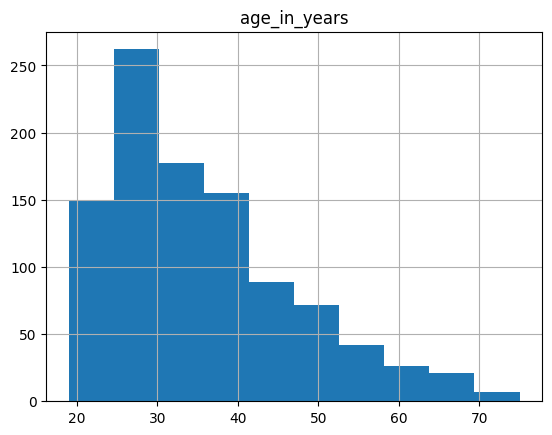

>>> Current breaks:
26.0,28.0,35.0,37.0 



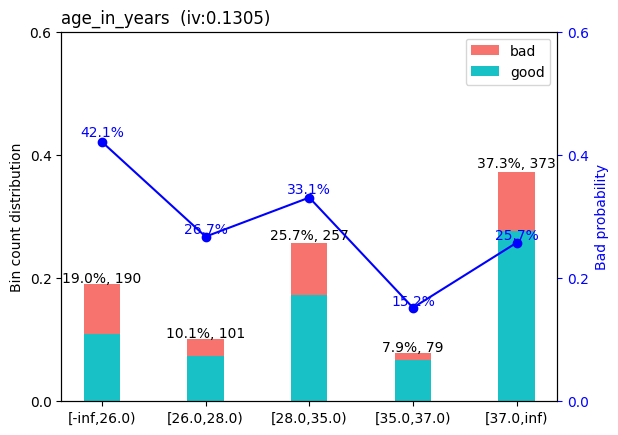

>>> Adjust breaks for (1/9) age_in_years?
1: next 
2: yes 
3: back


Selection:  1


-------- 2/9 credit_amount --------
>>> dt[credit_amount].describe(): 
count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: credit_amount, dtype: float64 



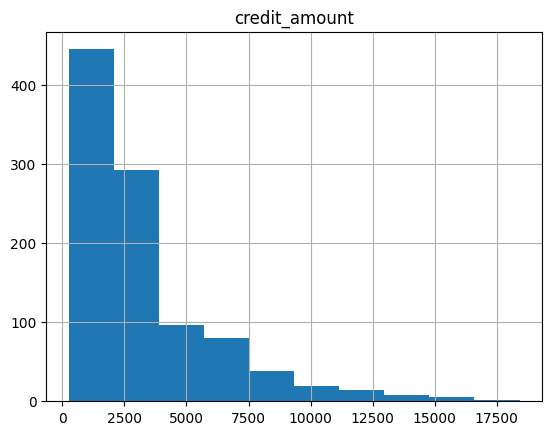

>>> Current breaks:
1400.0,1800.0,4000.0,9200.0 



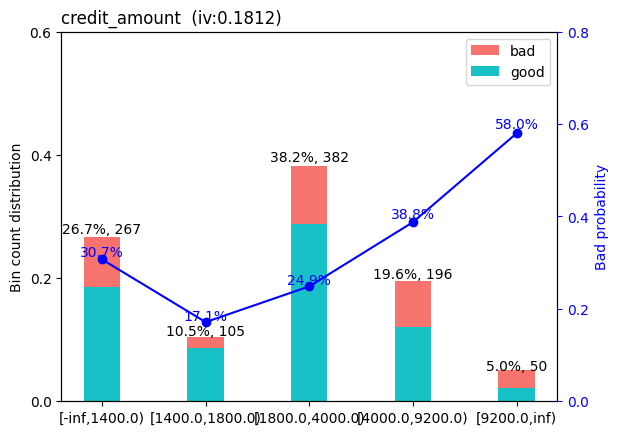

>>> Adjust breaks for (2/9) credit_amount?
1: next 
2: yes 
3: back


Selection:  1


-------- 3/9 credit_history --------
>>> dt[credit_history].describe(): 
count                                         1000
unique                                           5
top       existing credits paid back duly till now
freq                                           530
Name: credit_history, dtype: object 

>>> dt[credit_history].value_counts(): 
credit_history
existing credits paid back duly till now                       530
critical account/ other credits existing (not at this bank)    293
delay in paying off in the past                                 88
all credits at this bank paid back duly                         49
no credits taken/ all credits paid back duly                    40
Name: count, dtype: int64 

>>> Current breaks:
'no credits taken/ all credits paid back duly%,%all credits at this bank paid back duly','existing credits paid back duly till now','delay in paying off in the past','critical account/ other credits existing (not at this bank)' 



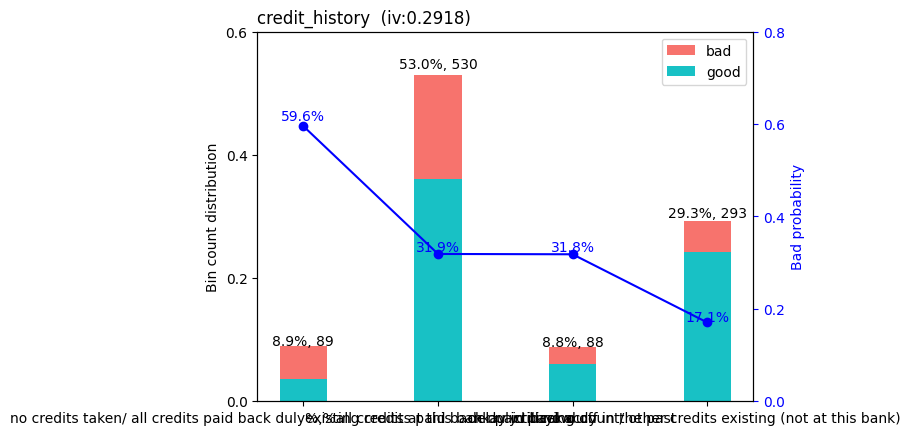

>>> Adjust breaks for (3/9) credit_history?
1: next 
2: yes 
3: back


Selection:  1


-------- 4/9 duration_in_month --------
>>> dt[duration_in_month].describe(): 
count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: duration_in_month, dtype: float64 



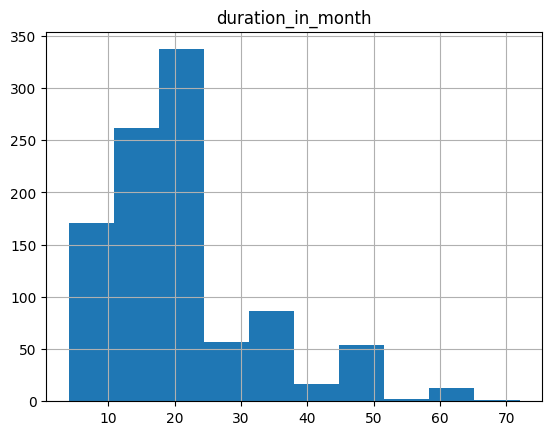

>>> Current breaks:
8.0,16.0,34.0,44.0 



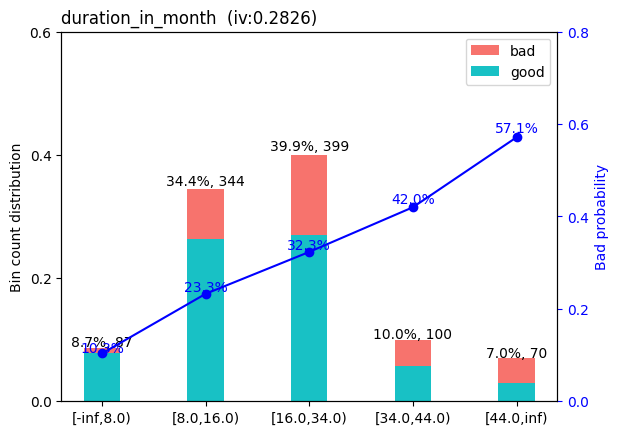

>>> Adjust breaks for (4/9) duration_in_month?
1: next 
2: yes 
3: back


Selection:  1


-------- 5/9 housing --------
>>> dt[housing].describe(): 
count     1000
unique       3
top        own
freq       713
Name: housing, dtype: object 

>>> dt[housing].value_counts(): 
housing
own         713
rent        179
for free    108
Name: count, dtype: int64 

>>> Current breaks:
'rent','own','for free' 



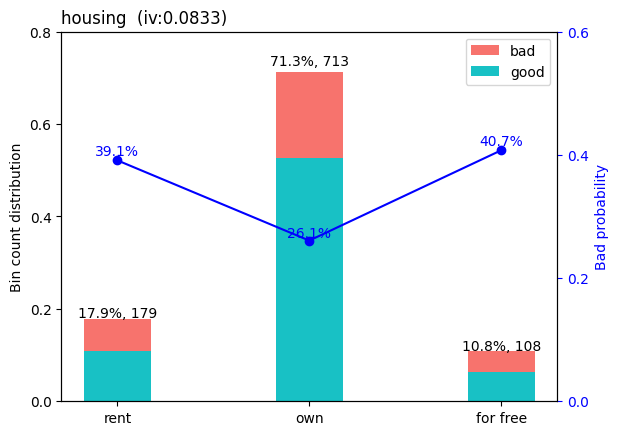

>>> Adjust breaks for (5/9) housing?
1: next 
2: yes 
3: back


Selection:  1


-------- 6/9 installment_rate_in_percentage_of_disposable_income --------
>>> dt[installment_rate_in_percentage_of_disposable_income].describe(): 
count    1000.000000
mean        2.973000
std         1.118715
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: installment_rate_in_percentage_of_disposable_income, dtype: float64 

>>> dt[installment_rate_in_percentage_of_disposable_income].value_counts(): 
installment_rate_in_percentage_of_disposable_income
4    476
2    231
3    157
1    136
Name: count, dtype: int64 

>>> Current breaks:
3.0,4.0 



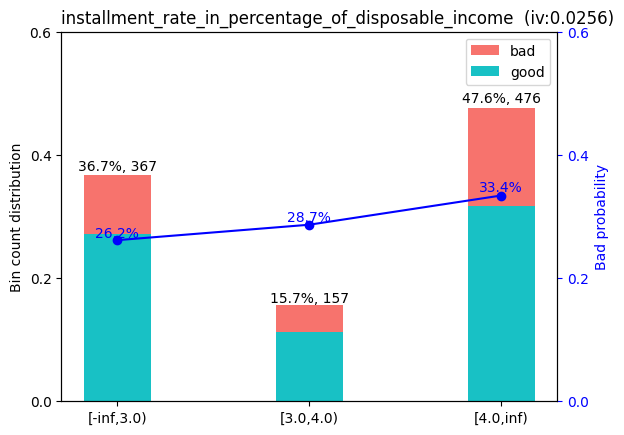

>>> Adjust breaks for (6/9) installment_rate_in_percentage_of_disposable_income?
1: next 
2: yes 
3: back


Selection:  1


-------- 7/9 present_employment_since --------
>>> dt[present_employment_since].describe(): 
count                   1000
unique                     5
top       1 <= ... < 4 years
freq                     339
Name: present_employment_since, dtype: object 

>>> dt[present_employment_since].value_counts(): 
present_employment_since
1 <= ... < 4 years    339
... >= 7 years        253
4 <= ... < 7 years    174
... < 1 year          172
unemployed             62
Name: count, dtype: int64 

>>> Current breaks:
'unemployed%,%... < 1 year','1 <= ... < 4 years','4 <= ... < 7 years','... >= 7 years' 



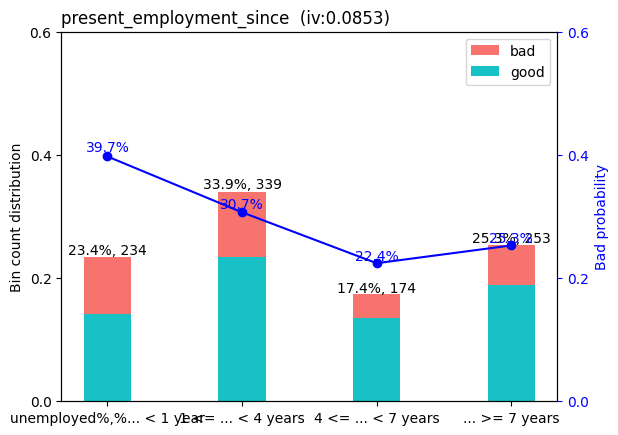

>>> Adjust breaks for (7/9) present_employment_since?
1: next 
2: yes 
3: back


Selection:  1


-------- 8/9 property --------
>>> dt[property].describe(): 
count                                                  1000
unique                                                    4
top       car or other, not in attribute Savings account...
freq                                                    332
Name: property, dtype: object 

>>> dt[property].value_counts(): 
property
car or other, not in attribute Savings account/bonds    332
real estate                                             282
building society savings agreement/ life insurance      232
unknown / no property                                   154
Name: count, dtype: int64 

>>> Current breaks:
'real estate','building society savings agreement/ life insurance','car or other, not in attribute Savings account/bonds','unknown / no property' 



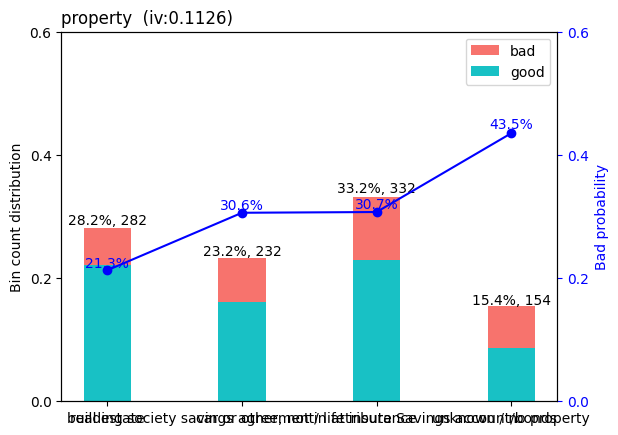

>>> Adjust breaks for (8/9) property?
1: next 
2: yes 
3: back


Selection:  1


-------- 9/9 status_of_existing_checking_account --------
>>> dt[status_of_existing_checking_account].describe(): 
count                    1000
unique                      4
top       no checking account
freq                      394
Name: status_of_existing_checking_account, dtype: object 

>>> dt[status_of_existing_checking_account].value_counts(): 
status_of_existing_checking_account
no checking account                                       394
... < 0 DM                                                274
0 <= ... < 200 DM                                         269
... >= 200 DM / salary assignments for at least 1 year     63
Name: count, dtype: int64 

>>> Current breaks:
'... < 0 DM%,%0 <= ... < 200 DM','... >= 200 DM / salary assignments for at least 1 year','no checking account' 



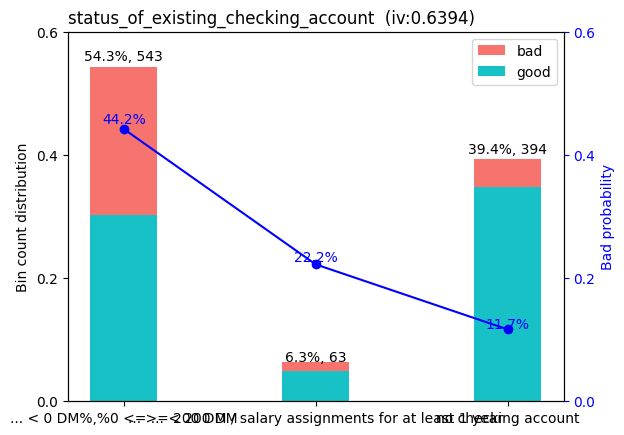

>>> Adjust breaks for (9/9) status_of_existing_checking_account?
1: next 
2: yes 
3: back


Selection:  1


In [18]:
# binning adjustment
# # adjust breaks interactively
breaks_adj = sc.woebin_adj(dt_s, "creditability", bins) 


In [19]:
 # or specify breaks manually
breaks_adj = {
    'age.in.years': [26, 35, 40],
    'other.debtors.or.guarantors': ["none", "co-applicant%,%guarantor"]
}
bins_adj = sc.woebin(dt_s, y="creditability", breaks_list=breaks_adj)

[INFO] creating woe binning ...


In [34]:
bins_adj.keys()

dict_keys(['duration_in_month', 'installment_rate_in_percentage_of_disposable_income', 'credit_amount', 'property', 'housing', 'status_of_existing_checking_account', 'age_in_years', 'savings_account_and_bonds', 'purpose', 'present_employment_since', 'other_installment_plans', 'other_debtors_or_guarantors', 'credit_history'])

In [35]:
bins_adj['duration_in_month']

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,duration_in_month,"[-inf,8.0)",87,0.087,78,9,0.103448,-1.312186,0.106849,0.282618,8.0,False
1,duration_in_month,"[8.0,16.0)",344,0.344,264,80,0.232558,-0.346625,0.038294,0.282618,16.0,False
2,duration_in_month,"[16.0,34.0)",399,0.399,270,129,0.323308,0.108688,0.004813,0.282618,34.0,False
3,duration_in_month,"[34.0,44.0)",100,0.100,58,42,0.420000,0.524524,0.029973,0.282618,44.0,False
4,duration_in_month,"[44.0,inf)",70,0.070,30,40,0.571429,1.134980,0.102689,0.282618,inf,False


In [20]:
# converting train and test into woe values
train_woe = sc.woebin_ply(train, bins_adj)
test_woe = sc.woebin_ply(test, bins_adj)

[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [36]:
train_woe

,creditability,duration_in_month_woe,installment_rate_in_percentage_of_disposable_income_woe,credit_amount_woe,property_woe,housing_woe,status_of_existing_checking_account_woe,age_in_years_woe,savings_account_and_bonds_woe,purpose_woe,present_employment_since_woe,other_installment_plans_woe,other_debtors_or_guarantors_woe,credit_history_woe
0,0,-1.312186,0.157300,0.033661,-0.461035,-0.194156,0.614204,-0.212371,-0.762140,-0.410063,-0.235566,-0.121179,0.027974,-0.733741
2,0,-0.346625,-0.190473,-0.258307,-0.461035,-0.194156,-1.176263,-0.212371,0.271358,0.279920,-0.394415,-0.121179,0.027974,-0.733741
4,1,0.108688,-0.064539,0.390539,0.586082,0.472604,0.614204,-0.212371,0.271358,0.279920,0.032103,-0.121179,0.027974,0.085158
5,0,0.524524,-0.190473,0.390539,0.586082,0.472604,-1.176263,-0.872488,-0.762140,0.279920,0.032103,-0.121179,0.027974,0.088319
6,0,0.108688,-0.064539,-0.258307,0.028573,-0.194156,-1.176263,-0.212371,-0.762140,0.279920,-0.235566,-0.121179,0.027974,0.088319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,-0.346625,-0.064539,-0.728239,-0.461035,-0.194156,-1.176263,0.142455,0.271358,0.279920,-0.394415,-0.121179,0.027974,0.088319
996,0,0.108688,0.157300,-0.258307,0.028573,-0.194156,0.614204,-0.212371,0.271358,-0.805625,0.032103,-0.121179,0.027974,0.088319
997,0,-0.346625,0.157300,0.033661,0.034191,-0.194156,-1.176263,-0.212371,0.271358,-0.410063,-0.235566,-0.121179,0.027974,0.088319
998,1,1.134980,0.157300,-0.258307,0.586082,0.472604,0.614204,0.528844,0.271358,-0.410063,0.032103,-0.121179,0.027974,0.088319


In [21]:
y_train = train_woe.loc[:,'creditability']
X_train = train_woe.loc[:,train_woe.columns != 'creditability']
y_test = test_woe.loc[:,'creditability']
X_test = test_woe.loc[:,train_woe.columns != 'creditability']

In [22]:
# logistic regression ------
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty='l1', C=0.9, solver='saga', n_jobs=-1)
lr.fit(X_train, y_train)
# lr.coef_
# lr.intercept_

LogisticRegression(C=0.9, n_jobs=-1, penalty='l1', solver='saga')

In [39]:
print(lr.coef_)
print()
print(lr.intercept_)

[[0.55271714 1.71949927 0.8271084  0.16037484 0.48855488 0.77366119
  0.82704866 0.55954424 1.00689578 0.27605727 0.69700618 0.76741811
  0.57335301]]

[-0.82648253]


In [23]:
# predicted proability
train_pred = lr.predict_proba(X_train)[:,1]
test_pred = lr.predict_proba(X_test)[:,1]

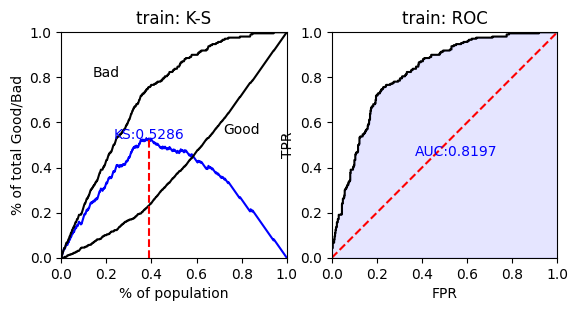

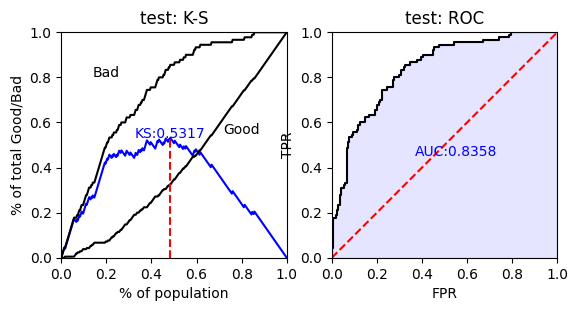

In [24]:
# performance ks & roc ------
train_perf = sc.perf_eva(y_train, train_pred, title = "train")
test_perf = sc.perf_eva(y_test, test_pred, title = "test")

In [25]:
# score ------
card = sc.scorecard(bins_adj, lr, X_train.columns)
# credit score
train_score = sc.scorecard_ply(train, card, print_step=0)
test_score = sc.scorecard_ply(test, card, print_step=0)

In [40]:
train_score

,score
0,568.0
2,602.0
4,351.0
5,531.0
6,568.0
...,...
995,559.0
996,471.0
997,549.0
998,325.0


In [31]:
card.keys()

dict_keys(['basepoints', 'duration_in_month', 'installment_rate_in_percentage_of_disposable_income', 'credit_amount', 'property', 'housing', 'status_of_existing_checking_account', 'age_in_years', 'savings_account_and_bonds', 'purpose', 'present_employment_since', 'other_installment_plans', 'other_debtors_or_guarantors', 'credit_history'])

In [32]:
card['duration_in_month']

,variable,bin,points
0,duration_in_month,"[-inf,8.0)",52.0
1,duration_in_month,"[8.0,16.0)",14.0
2,duration_in_month,"[16.0,34.0)",-4.0
3,duration_in_month,"[34.0,44.0)",-21.0
4,duration_in_month,"[44.0,inf)",-45.0


In [33]:
card['credit_amount']

,variable,bin,points
8,credit_amount,"[-inf,1400.0)",-2.0
9,credit_amount,"[1400.0,1800.0)",43.0
10,credit_amount,"[1800.0,4000.0)",15.0
11,credit_amount,"[4000.0,9200.0)",-23.0
12,credit_amount,"[9200.0,inf)",-70.0


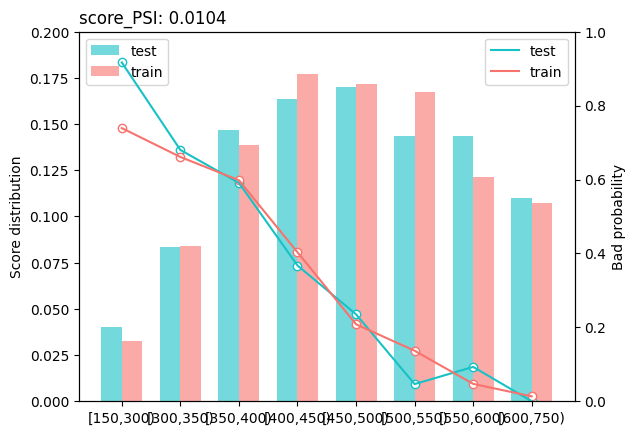

{'psi':   variable       PSI
 0    score  0.010375,
 'pic': {'score': <Figure size 640x480 with 2 Axes>}}

In [26]:
# psi
sc.perf_psi(
  score = {'train':train_score, 'test':test_score},
  label = {'train':y_train, 'test':y_test}
)